# Transport Map Density Demo: Banana Distribution

This notebook isolates the transport-map density estimators in `transport_map_density.py` on a nonlinear banana-shaped density. The success criterion is harder than the Gaussian smoke test: the learned quadratic triangular map should beat the affine map and recover the analytic banana log density with small held-out RMSE.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "transport_map_density.py").exists():
        PROJECT_ROOT = candidate
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not locate transport_map_density.py")

import matplotlib.pyplot as plt
import numpy as np

from transport_map_density import (
    fit_affine_transport_map_density,
    fit_quadratic_triangular_transport_map_density,
    standard_gaussian_logpdf,
)

SEED = 20260520
rng = np.random.default_rng(SEED)
PROJECT_ROOT

PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn')

## Generate a Nonlinear Banana Density

The base variable is standard Gaussian `z`. The observed sample is `x1 = z1`, `x2 = z2 + beta * (z1^2 - 1)`. This map has unit Jacobian, so the analytic banana log density is just the standard Gaussian log density of the inverse-transformed point.

In [2]:
BETA = 0.42

def banana_transform(base_samples: np.ndarray, *, beta: float = BETA) -> np.ndarray:
    samples = np.asarray(base_samples, dtype=float).copy()
    samples[:, 1] = samples[:, 1] + beta * (samples[:, 0] ** 2 - 1.0)
    return samples

def banana_inverse(samples: np.ndarray, *, beta: float = BETA) -> np.ndarray:
    base = np.asarray(samples, dtype=float).copy()
    base[:, 1] = base[:, 1] - beta * (base[:, 0] ** 2 - 1.0)
    return base

def banana_logpdf(samples: np.ndarray) -> np.ndarray:
    return standard_gaussian_logpdf(banana_inverse(samples))

train = banana_transform(rng.normal(size=(3500, 2)))
heldout = banana_transform(rng.normal(size=(1200, 2)))

affine_model = fit_affine_transport_map_density(train)
quadratic_model = fit_quadratic_triangular_transport_map_density(train)

heldout_log_true = banana_logpdf(heldout)
affine_log_hat = affine_model.log_prob(heldout)
quadratic_log_hat = quadratic_model.log_prob(heldout)

affine_rmse = float(np.sqrt(np.mean((affine_log_hat - heldout_log_true) ** 2)))
quadratic_rmse = float(np.sqrt(np.mean((quadratic_log_hat - heldout_log_true) ** 2)))

summary = {
    "seed": SEED,
    "beta": BETA,
    "n_train": int(train.shape[0]),
    "n_heldout": int(heldout.shape[0]),
    "affine_rmse_log_density": affine_rmse,
    "quadratic_tm_rmse_log_density": quadratic_rmse,
    "rmse_improvement_ratio": float(affine_rmse / quadratic_rmse),
    "quadratic_backend": quadratic_model.backend,
}
summary

{'seed': 20260520,
 'beta': 0.42,
 'n_train': 3500,
 'n_heldout': 1200,
 'affine_rmse_log_density': 0.6688948373806729,
 'quadratic_tm_rmse_log_density': 0.038682862329954285,
 'rmse_improvement_ratio': 17.291761702512655,
 'quadratic_backend': 'quadratic_triangular_transport_map'}

## Compare True, Affine, and Quadratic TM Densities

The affine estimator cannot bend its contours. The quadratic triangular estimator learns the curved conditional mean of `x2 | x1`, which is exactly the structure that creates the banana.

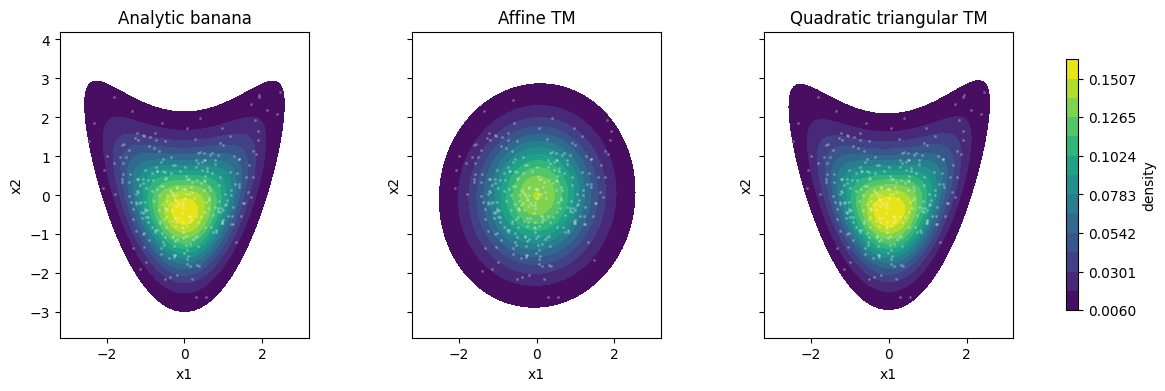

In [3]:
x = np.linspace(-3.2, 3.2, 180)
y = np.linspace(-3.2, 4.2, 180)
xx, yy = np.meshgrid(x, y)
grid = np.column_stack([xx.ravel(), yy.ravel()])

true_pdf = np.exp(banana_logpdf(grid)).reshape(xx.shape)
affine_pdf = affine_model.pdf(grid).reshape(xx.shape)
quadratic_pdf = quadratic_model.pdf(grid).reshape(xx.shape)

positive_max = max(float(true_pdf.max()), float(quadratic_pdf.max()))
levels = np.linspace(0.006, positive_max, 14)

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8), constrained_layout=True, sharex=True, sharey=True)
for ax, density, label in zip(
    axes,
    [true_pdf, affine_pdf, quadratic_pdf],
    ["Analytic banana", "Affine TM", "Quadratic triangular TM"],
):
    contour = ax.contourf(xx, yy, density, levels=levels, cmap="viridis")
    ax.scatter(train[:300, 0], train[:300, 1], s=4, c="white", alpha=0.30, linewidths=0)
    ax.set_title(label)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
fig.colorbar(contour, ax=axes, shrink=0.82, label="density")
plt.show()

## Reference-Space Diagnostic

A usable transport map should send observed banana samples back to an approximately standard Gaussian reference. The scatter below shows the learned quadratic map in reference coordinates.

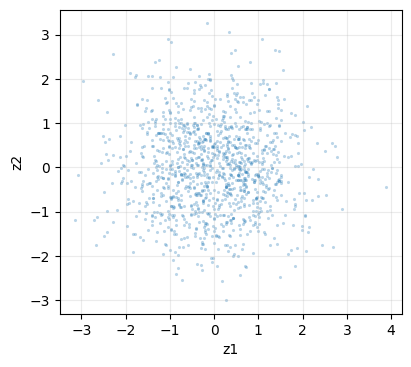

{'reference_mean': [-0.036, -0.002],
 'reference_covariance': [[1.035, -0.019], [-0.019, 0.999]]}

In [4]:
reference = quadratic_model.map_to_reference(heldout)
reference_summary = {
    "reference_mean": np.mean(reference, axis=0).round(3).tolist(),
    "reference_covariance": np.cov(reference, rowvar=False).round(3).tolist(),
}

fig, ax = plt.subplots(figsize=(4.0, 4.0), constrained_layout=True)
ax.scatter(reference[:, 0], reference[:, 1], s=5, alpha=0.30, linewidths=0)
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
plt.show()
reference_summary

## Minimal Dependency Check

This notebook intentionally does not import `yrd`, `utils.py`, or `density_benchmark.py`. If this notebook runs, the banana experiment is reproducible from `transport_map_density.py` plus standard plotting/data-generation packages.